# FINAL Model

## There are two sections, the first is the many trial & errors - the second is the final graphs

## Trail and Errors

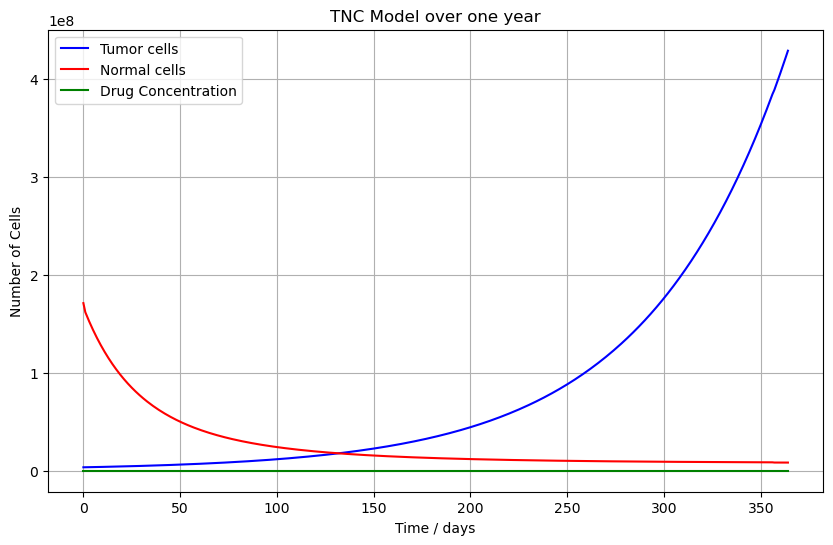

In [4]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

#Parameters
T0 = 3500000 #number of tumor cells
N0 = 171000000 #number of normal cells
C0 = 61.6 #Drug concentration (mg)
rT = 0.014 #Rate of tumor growth (days)
rN = 0 #Normal cell growth
#K = 171000000 #Carrying Capacity - how many cells the organ can hold
alpha = 0.0005 #Chemo kill rate for tumor - Tumor cells are more senetive to Chemo
beta = 0.00005 #Chemo kill rate for normal cells 
m = 0.01 #how fast bodies metabloizes the drug - (16 minutes -> days)
dose = 100 #(mg)
interval = 18
#Equations
def model(y, t, alpha, beta):
    T, N, C = y
    
    if abs(t % 21) < 0.5:
        C += dose
        
    dTdt = rT*T - alpha*C*T #1 - ((T+N)/K)
    dNdt = rN*N - beta*C*N #(1- ((T+N)/K))
    dCdt = -m*C
    return [dTdt, dNdt, dCdt]

t = np.linspace(0, 365, 365) # simulation over 1 year

#conditions
y0 = [T0, N0, C0]

ret = odeint(model, y0, t, args=(beta, alpha)) # Integrate the SIS equations over the time grid, t
T, N, C = ret.T


#Plot!
plt.figure(figsize=(10, 6))
plt.plot(T, 'b', label='Tumor cells')
plt.plot(N, 'r', label='Normal cells')
plt.plot(C, 'g', label='Drug Concentration')
plt.title('TNC Model over one year')
plt.xlabel('Time / days')
plt.ylabel('Number of Cells')
plt.legend()
plt.grid(True)
plt.show()

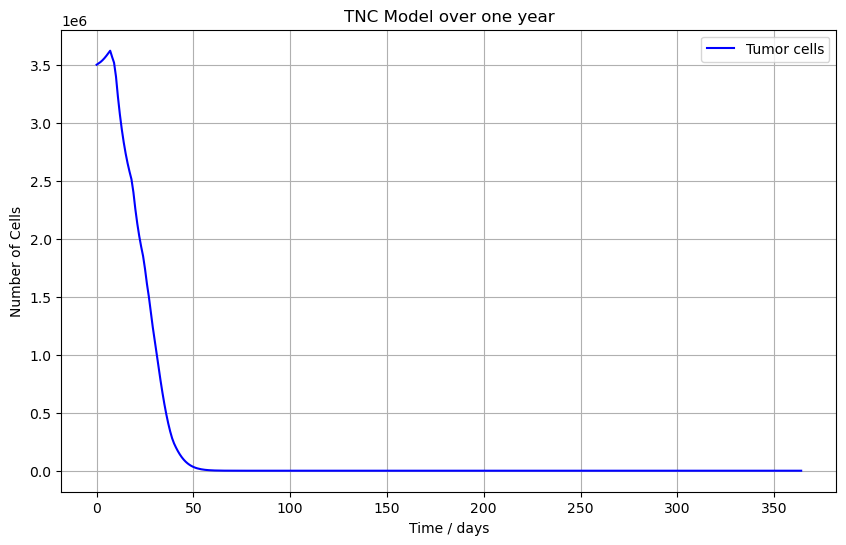

In [5]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

T10 = 3500000 #number of tumor cells
rT1 = 0.014 #Rate of tumor growth (days)
beta = 0.00158 #Chemo kill rate for tumor - Tumor cells are more senetive to Chemo
m1 = 0.079 #how fast bodies metabloizes the drug
t = np.linspace(0, 365, 365) # simulation over 1 year

def dosing1(t):
    return 75 if abs(t - round(t)) < 0.1 else 0

def model_T1(y1, t, alpha):
    T1, C1 = y1 
    
    dT1dt = rT1*T1 - alpha*C1*T1
    dC1dt = -m1*C1 + dosing1(t)

    return [dT1dt, dC1dt]

y10 = [T10, 0]

ret = odeint(model_T1, y10, t, args=(beta,)) # Integrate the SIS equations over the time grid, t
T1, C1 = ret.T

plt.figure(figsize=(10, 6))
plt.plot(T1, 'b', label='Tumor cells')
plt.title('TNC Model over one year')
plt.xlabel('Time / days')
plt.ylabel('Number of Cells')
plt.legend()
plt.grid(True)
plt.show()

#plt.figure(figsize=(10, 6))
#plt.plot(C1, 'g', label='Drug Dose')
#plt.title('TNC Model over one year')
#plt.xlabel('Time / days')
#plt.ylabel('Drug Dose (mg)')
#plt.legend()
#plt.grid(True)
#plt.show()


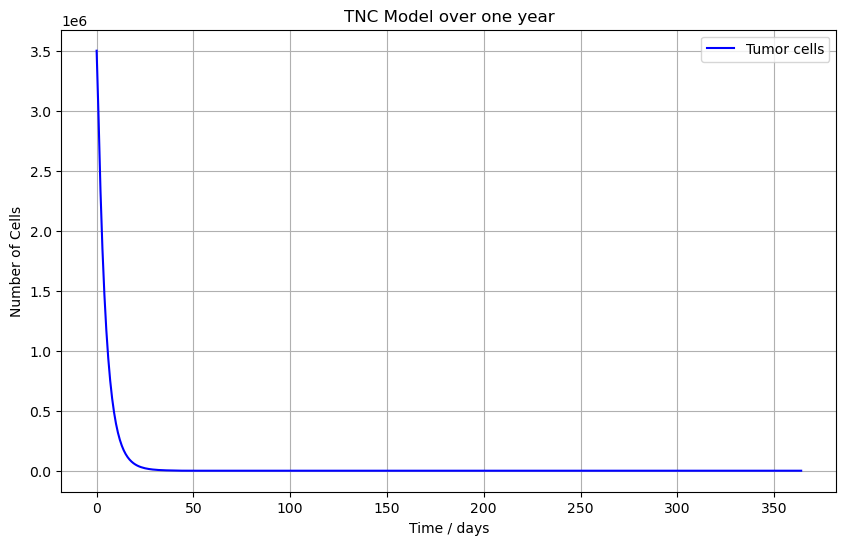

In [6]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

dose_times = [0, 42, 84, 126, 168, 210]
dose_amount = 100 #mg

m = 0.01 #how fast bodies metabloizes the drug - (16 minutes -> days)
T0 = 3500000 #number of tumor cells
rT = 0.014 #Rate of tumor growth (days)
alpha = 0.005 #Chemo kill rate for tumor - Tumor cells are more senetive to Chemo
t = np.linspace(0, 365, 365) # simulation over 1 year

def dosing(t):
    return dose_amount if any(abs(t - d) < 0.5 for d in dose_times) else 0

def model_T(y, t, alpha):
    T, C = y 
    
    dTdt = rT*T - alpha*C*T
    dCdt = -m*C + dosing(t) #units mismatch: dosing(t) is in mg and dCdt is in concentration/unit time

    return [dTdt, dCdt]

y0 = [T0, 0]

ret = odeint(model_T, y0, t, args=(alpha,)) # Integrate the SIS equations over the time grid, t
T = ret[:, 0]
C = ret[:, 1]

#print(C)
#plt.figure(figsize=(10, 6))
#plt.plot(C, 'g', label='Drug Dose')
#plt.title('TNC Model over one year')
#plt.xlabel('Time / days')
#plt.ylabel('Drug Dose (mg)')
#plt.legend()
#plt.grid(True)
#plt.show()

plt.figure(figsize=(10, 6))
plt.plot(T, 'b', label='Tumor cells')
#plt.plot(T1, 'g', label='Tumor 2 cells')
plt.title('TNC Model over one year')
plt.xlabel('Time / days')
plt.ylabel('Number of Cells')
plt.legend()
plt.grid(True)
plt.show()



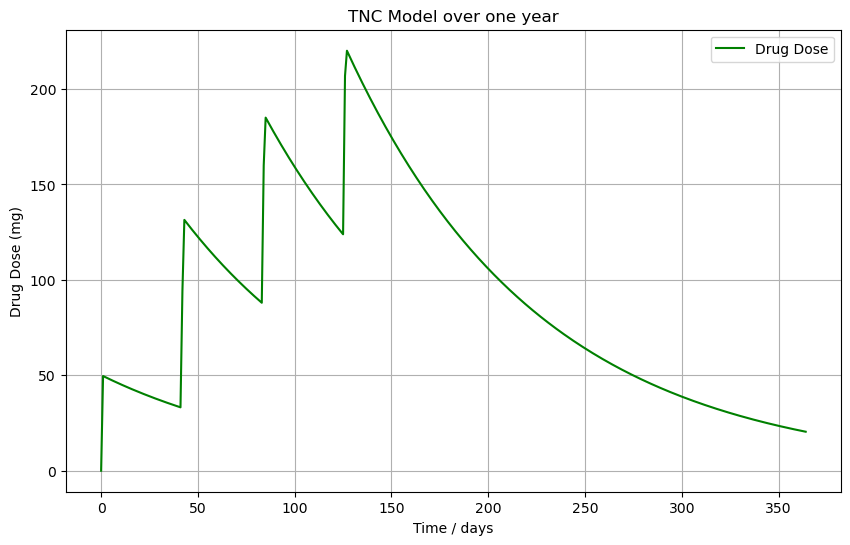

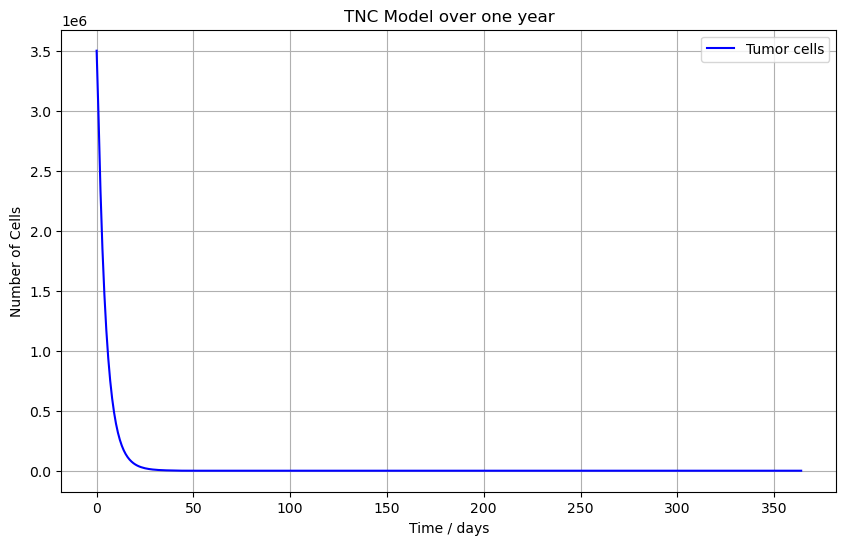

In [7]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

dose_times = [0, 42, 84, 126, 168, 210]
dose_amount = 100 #mg

m = 0.01 #how fast bodies metabloizes the drug - (16 minutes -> days)
T0 = 3500000 #number of tumor cells
rT = 0.014 #Rate of tumor growth (days)
alpha = 0.005 #Chemo kill rate for tumor - Tumor cells are more senetive to Chemo
t = np.linspace(0, 365, 365) # simulation over 1 year

def dosing(t):
    return dose_amount if any(abs(t - d) < 0.5 for d in dose_times) else 0

def model_T(y, t, alpha):
    T, C = y 
    
    dTdt = rT*T - alpha*C*T
    dCdt = -m*C + dosing(t) #units mismatch: dosing(t) is in mg and dCdt is in concentration/unit time

    return [dTdt, dCdt]

y0 = [T0, 0]

ret = odeint(model_T, y0, t, args=(alpha,)) # Integrate the SIS equations over the time grid, t
T = ret[:, 0]
C = ret[:, 1]

#print(C)
plt.figure(figsize=(10, 6))
plt.plot(C, 'g', label='Drug Dose')
plt.title('TNC Model over one year')
plt.xlabel('Time / days')
plt.ylabel('Drug Dose (mg)')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(T, 'b', label='Tumor cells')
#plt.plot(T1, 'g', label='Tumor 2 cells')
plt.title('TNC Model over one year')
plt.xlabel('Time / days')
plt.ylabel('Number of Cells')
plt.legend()
plt.grid(True)
plt.show()

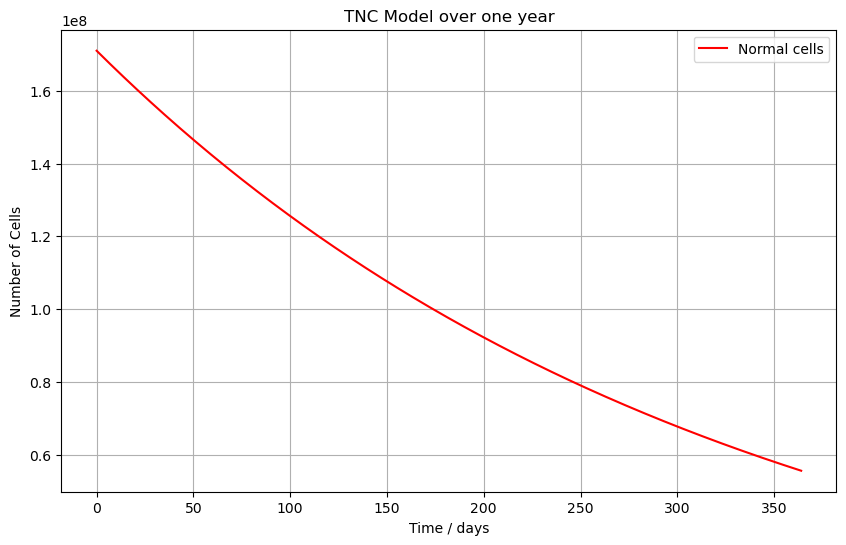

In [8]:
N0 = 171000000 #number of normal cells
rN = 0 #Normal cell growth
beta = 0.00005 #Chemo kill rate for normal cells 
C = 61.6 

def model_N(y, t, alpha):
    N = y[0] 
    dNdt = rN*N - beta*C*N
    return [dNdt]

y0 = [N0]

ret = odeint(model_N, y0, t, args=(alpha,)) # Integrate the SIS equations over the time grid, t
N = ret[:, 0]

plt.figure(figsize=(10, 6))
plt.plot(N, 'r', label='Normal cells')
plt.title('TNC Model over one year')
plt.xlabel('Time / days')
plt.ylabel('Number of Cells')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
#Parameters istg there is 8 million.

import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt
import math
t = np.linspace(0, 365, 365)

ka = 1.0  # Kind of found? 1/day  (absorption: fairly fast)
kpb = 0.15  # 1/day   (blood → brain)
kbt = 0.5  # 1/day   (brain → tumor)
ke = 0.075   # 1/day   (elimination from blood)
kel = 0.07   # 1/day   (elimination from tumor)
gamma = 1.0   # scaling factor
k = 0 #no evidence of brain cell division
ktox = 1e-7 #how effected the normal cells are by chem
beta = 0.00000001 #effect of normal cells (immune cells) on tumor cells - almost 0 since the tumor cells 'discies' themselves as "normal" cells
alpha = 0.014


dose_times = []
for cycle in range(6):
    for day in range(1, 6):
        dose_times.append(cycle * 28 + day)
        
d = 150 #<3 (mg)
sigma = 0.05  # width of dose (days) - how fast the dose is given
kg = 0.0014 # <3 - 1/day (tumor growth rate)
Pmax = 1e9  # max tumor size (cells)

kill = 0.00001 #1/mg*day


#inital conditions
y0 = 0
Cp0 = 0
Cb0 = 0 
Ct0 = 0
N0 = 1e9
P0 = 30700000 #<3 inital number of cells

a0 = [y0, Cp0, Cb0, Ct0]

In [10]:
t= np.linspace(0, 365, 1000)
from scipy.integrate import solve_ivp

volume = 65.22 #average volume of a human - https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=3&id=109718
dose = 150 #mg
ka = 1.0 # elimination rate 1/day
c0 = dose/volume
    
def body_system_T(t, a):
    y, Cp, Cb, Ct = a 
    dydt = - ka*y
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp)
    dCbdt = (kpb*Cp) - (kbt*Cb)
    dCtdt = (kbt*Cb) - (kel*Ct)
    
    return [dydt, dCpdt, dCbdt, dCtdt]
    
state = [y0, Cp0, Cb0, Ct0,]
t_start = 0

t_all = []
y_all = []

for tdose in dose_times: 
    sol = solve_ivp(body_system_T, (t_start, tdose), state) #what happens between each dose
    t_all.extend(sol.t) #makes a continuos curve out of little curves
    y_all.extend(sol.y.T) #makes continuos curve from little curves
    state = sol.y[:, -1] #Takes the final value of the system (becomes starting point for next loop)
    state[0] += dose #adding the dose to y0
    t_start = tdose #starting the loop back again

sol = solve_ivp(body_system_T, (t_start, t[-1]), state, t_eval=np.linspace(t_start, t[-1], 1000))
t_all.extend(sol.t)
y_all.extend(sol.y.T)

y_all = np.array(y_all)
Ct_vals = y_all[:, 3]

def cell_systems(a, t):
    P, N = a
    
    idx = int(t / t_all[-1] * (len(t_all)-1))
    Ct = Ct_vals[idx]

    dPdt = (-kg * P * np.log(P / Pmax)) - kill * Ct * P
    dNdt = -ktox * Ct * N - beta*P*N
    return [dPdt, dNdt]

tumor_sol = odeint(cell_systems, [P0, N0], t_all)

P = tumor_sol[:,0]
N = tumor_sol[:,1]


plt.figure(figsize=(10,6))
plt.plot(t_all, P, label='Tumor Cell population')
plt.plot(t_all, N, label='Normal Population of Brain Cells')
plt.xlabel('Time (days)')
plt.ylabel('Drug Amount (mg)')
plt.title('Effect of Temozolomide on tumor and brain cell populations')
plt.legend()
plt.grid(True)
plt.show()

IndexError: index 1239 is out of bounds for axis 0 with size 1210

#### Temozolomide

In [11]:
t = np.linspace(0, 365, 700)
alpha = 0.014
beta = 0.00000001


r = 0 #growth of brain cells
def R_func(t):
    return sum(d/sigma * np.exp(-((t - ti)**2)/(sigma**2)) for ti in dose_times)


def body_system_T(a, t):
    y, Cp, Cb, Ct, P, N = a 

    R = R_func(t)
    
    dydt = - ka*y      #y (mg) ka (1/day) dydt (mg/day) R = mg/day # The units here are mismatched???? R is in mg or something and dydt is a rate of change, so the denominator should be time. 
    
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp) #dCpdt= Drug concentration entering the plasma (mg/day)
    #(absorption in gut*Scalaing factor*Concentration in gut) - (transfer rate from plas -> brain* concentration in plasma) - (elimination rate from plama*Concentration in plasma)
    
    dCbdt = (kpb*Cp) - (kbt*Cb) #dCbdt= Drug Concentration entering the brain (mg/day)
    #(transfer rate from plasma -> brain) - (transfer rate from brain -> tumor *Concentration in Brain)
    
    dCtdt = (kbt*Cb) - (kel*Ct)#dCtdt= Drug Concentration entering the tumor (mg/day)
    #(transfer rate from brain ->tumor * amount in brain) - (elimination rate from tumor*concentration in tumor)

    dPdt = -alpha * P * np.log(P / Pmax) - kill * Ct * P - beta * P * N
    
    #P = (Pmax*e**(np.log(P/Pmax)*(e**(-alpha*t)))) -Ct*kill*P -beta*P*N    #Try (kg*P*(1-(P/Pmax))) - kill*Ct*P    ##-beta*P*N
    #Growth function (Gompertz function) - (Concentration of drug * how effected tumor cells are * population) - (Rate at which immume system gets tumor cells)
    
    #dNdt = - ktox*Cb*N - (Pmax + P) #Try -(const)*P - ktox*Cb*N  #dNdt= The tumor AND drug effect on normal cells ##Beta is the effect of the normal on the 
    dNdt = - ktox*Cb*N - beta*P*N
    
    return [dydt, dCpdt, dCbdt, dCtdt, dPdt, dNdt]



    
ret_body = odeint(body_system_T, a0, t)
P = ret_body[:,4]
N = ret_body[:,5]

y_axis = [Pmax] *len(t)

#Plot!
#plt.figure(figsize=(10,6))
#plt.plot(t, P, 'hotpink', label='Tumor Cell Population')
#plt.plot(t, N, 'orange' , label='Normal healthy Cell Population')
#plt.plot(t, y_axis, 'b--', label='Carrying Capacity') 
#plt.title('Model of Temozolomide effecting a Glioblastoma tumor and Normal Cells')
#plt.xlabel('Time/ Days')
#plt.ylabel('Number of cells')
#plt.legend()
#plt.grid(True)
#plt.show()

ValueError: not enough values to unpack (expected 6, got 4)

In [12]:
t = np.linspace(0, 365, 6)
alpha = 0.132
kg = 0.05
kill = 0.00001

def R_func(t):
    return sum(d/sigma * np.exp(-((t - ti)**2)/(sigma**2)) for ti in dose_times)


def body_system_T(a, t):
    y, Cp, Cb, Ct, P, N = a 
    
    R = R_func(t)
    
    dydt = R - ka*y      #y (mg) ka (1/day) dydt (mg/day) R = mg/day # The units here are mismatched???? R is in mg or something and dydt is a rate of change, so the denominator should be time. 
    
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp) #dCpdt= Drug concentration entering the plasma (mg/day)
    #(absorption in gut*Scalaing factor*Concentration in gut) - (transfer rate from plas -> brain* concentration in plasma) - (elimination rate from plama*Concentration in plasma)
    
    dCbdt = (kpb*Cp) - (kbt*Cb) #dCbdt= Drug Concentration entering the brain (mg/day)
    #(transfer rate from plasma -> brain) - (transfer rate from brain -> tumor *Concentration in Brain)
    
    dCtdt = (kbt*Cb) - (kel*Ct)#dCtdt= Drug Concentration entering the tumor (mg/day)
    #(transfer rate from brain ->tumor * amount in brain) - (elimination rate from tumor*concentration in tumor)
    
    dPdt = (kg*P*(1-(P/Pmax))) - kill*Ct*P
    #Pmax**(math.log(P/Pmax)**alpha*t)- kill*Ct*(P+N) - (Pmax + N)    #Try (kg*P*(1-(P/Pmax))) - kill*Ct*P 
    
    dNdt = - ktox*Cb*N - (Pmax + P) #Try -(const)*P - ktox*Cb*N  #dNdt= The tumor AND drug effect on normal cells ##Beta is the effect of the normal on the 
    
    return [dydt, dCpdt, dCbdt, dCtdt, dPdt, dNdt]
    
ret_body = odeint(body_system_T, a0, t)
P = ret_body[:,4]
N = ret_body[:,5]

y_axis = [Pmax] *len(t)

#Plot!
plt.figure(figsize=(10,6))
plt.plot(t, P, 'hotpink', label='Tumor Cell Population')
plt.plot(t, N, 'orange' , label='Normal healthy Cell Population')
#plt.plot(t, y_axis, 'b--', label='Carrying Capacity') 
plt.title('Model of Temozolomide effecting a Glioblastoma tumor and Normal Cells')
plt.xlabel('Time/ Days')
plt.ylabel('Number of cells')
plt.legend()
plt.grid(True)
plt.show()

ValueError: not enough values to unpack (expected 6, got 4)

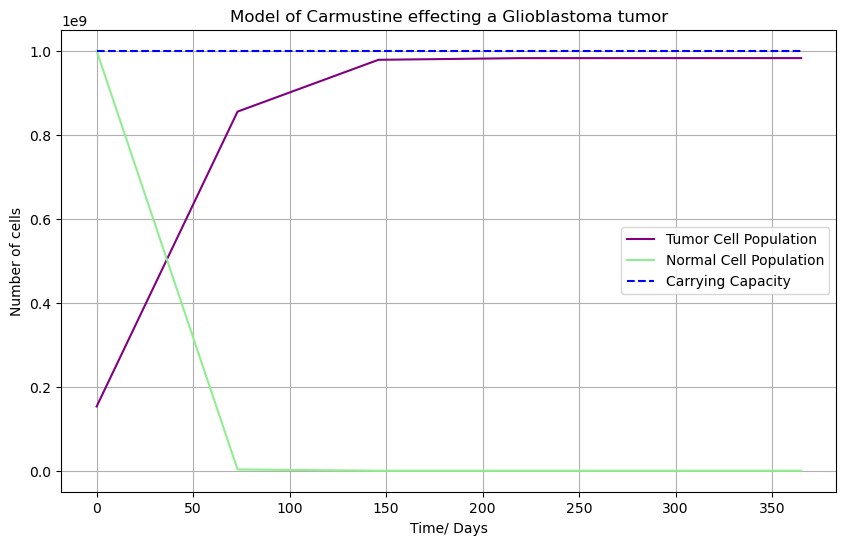

In [13]:
F = 12.3 #mg/day

m0 = 0
W0 = 153000000 # we assume small amount since the wafers are put in after tumor removal
km = 0.14
kill1 = 1e-5
ktox1 = 0.001 #more localized toxicity

b0 = [m0, W0, N0]

def body_system_C(b,t):
    m, W, N = b
 
    dmdt = F - km*m
    dWdt = (kg*W*(1-(W/Pmax))) - kill1*m*W
    dNordt = -k*W - ktox1*m*N
  
    return [dmdt, dWdt, dNordt]
    
ret_body = odeint(body_system_C, b0, t)
W = ret_body[:,1]
Nor = ret_body[:,2]
y_axis = [Pmax] * len(t)

plt.figure(figsize=(10,6))
plt.plot(t, W, 'purple', label='Tumor Cell Population')
plt.plot(t, Nor, 'lightgreen', label='Normal Cell Population')
plt.plot(t, y_axis, 'b--', label='Carrying Capacity') 
plt.title('Model of Carmustine effecting a Glioblastoma tumor')
plt.xlabel('Time/ Days')
plt.ylabel('Number of cells')
plt.legend()
plt.grid(True)
plt.show()



In [14]:

import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
cycle_length = 28  # days
k = 5              # smoothness (higher = sharper transitions)

# Dose levels (mg/m^2)
A_high = 150
A_low = 75   # choose within 50–100 range

# --- Sigmoid function ---
def S(x):
    return 1 / (1 + np.exp(-k * x))

# --- Smooth pulse between a and b ---
def pulse(t, a, b):
    return S(t - a) - S(t - b)

# --- Main dosing function ---
def D(t):
    t_mod = np.mod(t, cycle_length)
    
    high_1 = A_high * pulse(t_mod, 1, 6)
    high_2 = A_high * pulse(t_mod, 10, 15)
    low = A_low * pulse(t_mod, 1, 22)
    
    return high_1 + high_2 + low

# --- Time range ---
t = np.linspace(0, 84, 1000)  # 3 cycles

# --- Compute dose ---
dose = D(t)

# --- Plot ---
##plt.plot(t, dose)
#lt.xlabel("Time (days)")
#plt.ylabel("Dose (mg/m^2)")
#plt.title("Continuous Approximation of Dosing Schedule")
#plt.grid()

#plt.show()

ValueError: x and y must have same first dimension, but have shapes (1000,) and (6,)

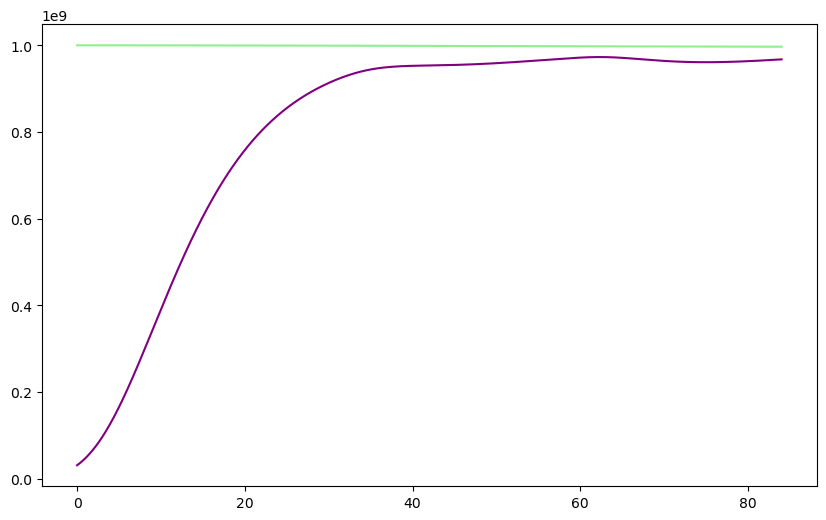

In [15]:
from scipy.interpolate import interp1d

def pk_system(a, t):
    y, Cp, Cb, Ct = a
    R = R_func(t)
    
    dydt = R - ka*y      #y (mg) ka (1/day) dydt (mg/day) R = mg/day # The units here are mismatched???? R is in mg or something and dydt is a rate of change, so the denominator should be time. 
    
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp) #dCpdt= Drug concentration entering the plasma (mg/day)
    #(absorption in gut*Scalaing factor*Concentration in gut) - (transfer rate from plas -> brain* concentration in plasma) - (elimination rate from plama*Concentration in plasma)
    
    dCbdt = (kpb*Cp) - (kbt*Cb) #dCbdt= Drug Concentration entering the brain (mg/day)
    #(transfer rate from plasma -> brain) - (transfer rate from brain -> tumor *Concentration in Brain)
    
    dCtdt = (kbt*Cb) - (kel*Ct)#dCtdt= Drug Concentration entering the tumor (mg/day)
    #(transfer rate from brain ->tumor * amount in brain) - (elimination rate from tumor*concentration in tumor)
    
    return [dydt, dCpdt, dCbdt, dCtdt]

def pd_system(a, t, Ct):
    P, N = a
    dPdt = -alpha * P * np.log(P / Pmax) - kill * Ct * P
    dNdt = -ktox * Ct * N
    return [dPdt, dNdt]


pk_sol = odeint(pk_system, [y0, Cp0, Cb0, Ct0], t)
Ct_vals = pk_sol[:, 3]

Ct_func = interp1d(t, Ct_vals, fill_value="extrapolate")

def tumor_system(a, t):
    P, N = a
    Ct = Ct_func(t)

    dPdt = -alpha * P * np.log(P / Pmax) - kill * Ct * P
    dNdt = -ktox * Ct * N

    return [dPdt, dNdt]

tumor_sol = odeint(tumor_system, [P0, N0], t)

P = tumor_sol[:,0]
N = tumor_sol[:,1]

plt.figure(figsize=(10,6))
plt.plot(t, P, 'purple', label='Tumor Cell Population')
plt.plot(t, N, 'lightgreen', label='Normal Cell Population')
plt.plot(t, y_axis, 'b--', label='Carrying Capacity') 
plt.title('Model of Carmustine effecting a Glioblastoma tumor')
plt.xlabel('Time/ Days')
plt.ylabel('Number of cells')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.integrate import solve_ivp
t = np.linspace(0, 365, 365)

dose_times = [] #Days
for cycle in range(6):
    for day in range(1, 6):
        dose_times.append(cycle * 28 + day)


def pk_system(t, a):
    y, Cp, Cb, Ct = a
    
    dydt = - ka*y
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp)
    dCbdt = (kpb*Cp) - (kbt*Cb) 
    dCtdt = (kbt*Cb) - (kel*Ct)
    
    return [dydt, dCpdt, dCbdt, dCtdt]

def pd_system(a, t, Ct):
    P, N = a
    dPdt = -alpha * P * np.log(P / Pmax) - kill * Ct * P
    dNdt = -ktox * Ct * N
    return [dPdt, dNdt]

t_end = 365
t_points = [0]
pk_points = [[y0, Cp0, Cb0, Ct0]]

t_current = 0
pk_current = np.array([y0, Cp0, Cb0, Ct0])

for tdose in dose_times:
    sol = solve_ivp(pk_system, (t_current, tdose), pk_current,t_eval=np.linspace(t_current, tdose, 200))

    t_points.extend(sol.t[1:])
    pk_points.extend(sol.y.T[1:])

    pk_current = sol.y[:, -1]
    pk_current[0] += dose 

    t_current = tdose

sol = solve_ivp(pk_system, (t_current, t_end), pk_current,
                t_eval=np.linspace(t_current, t_end, 400))

t_points.extend(sol.t)
pk_points.extend(sol.y.T)

t_points = np.array(t_points)
pk_points = np.array(pk_points)


Ct_vals = pk_points[:, 3]
Ct_func = interp1d(t_points, Ct_vals, fill_value="extrapolate")


def tumor_system(t, a):
    P, N = a
    Ct = Ct_func(t)

    dPdt = -alpha * P * np.log(P / Pmax) - kill * Ct * P
    dNdt = -ktox * Ct * N

    return [dPdt, dNdt]


sol_pd = solve_ivp(tumor_system, (t_points[0], t_points[-1]),[P0, N0], t_eval=t_points)

P = sol_pd.y[0]
N = sol_pd.y[1]



plt.figure(figsize=(10,6))
plt.plot(t, P, 'purple', label='Tumor Cell Population')
plt.plot(t, N, 'lightgreen', label='Normal Cell Population')
#plt.plot(t, y_axis, 'b--', label='Carrying Capacity') 
plt.title('Model of Carmustine effecting a Glioblastoma tumor')
plt.xlabel('Time/ Days')
plt.ylabel('Number of cells')
plt.legend()
plt.grid(True)
plt.show()

ValueError: setting an array element with a sequence.

## Final Graphs !!!! 

### Temozolomide

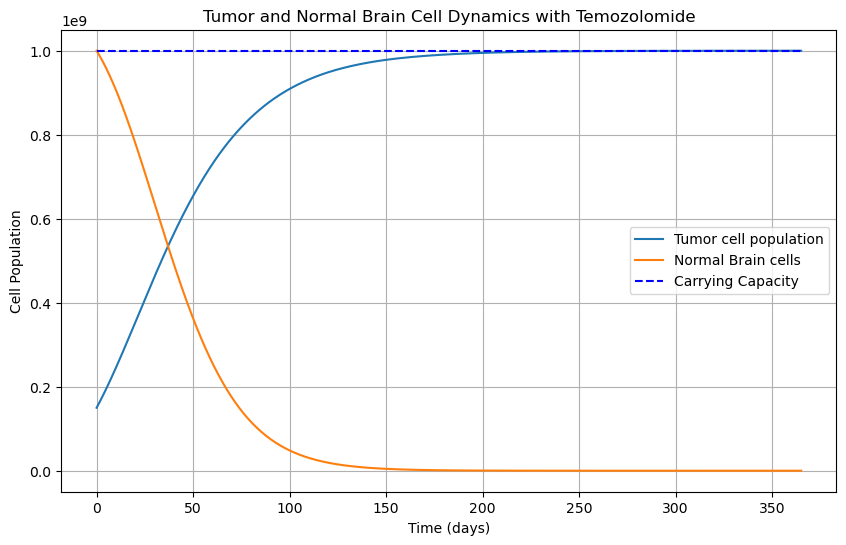

In [10]:
#Parameters:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import math

ka = 1.0  # 1/day  (absorption: fairly fast)
kpb = 0.15  # 1/day   (blood → brain)
kbt = 0.5  # 1/day   (brain → tumor)
ke = 0.075   # 1/day   (elimination from blood)
kel = 0.07   # 1/day   (elimination from tumor)
gamma = 1.0   # scaling factor
k = 0 #no evidence of brain cell division
ktox = 1e-7 #how effected the normal cells are by chemo
beta = 0.5e-10 #effect of normal cells (immune cells) on tumor cells - almost 0 since the tumor cells 'disguises' themselves as "normal" cells
Nmax = 1e9 #max number of brain cells 

dose_times = [] #Days
for cycle in range(6):
    for day in range(1, 6):
        dose_times.append(cycle * 28 + day)

dose = 150 #<3 (mg)
kg = 0.03 # <3 - 1/day (tumor growth rate)
Pmax = 1e9  # max tumor size (cells)
kill = 1e-7 #1/mg*day

#inital conditions
y0 = 0
Cp0 = 0
Cb0 = 0
Ct0 = 0
N0 = 1e9
P0 = 1.5e8 #<3 inital number of cells

a0 = [y0, Cp0, Cb0, Ct0, P0, N0]


def body_system_a(t, a):
    y, Cp, Cb, Ct, P, N = a 
    #Drug movement
    dydt = - ka*y
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp)
    dCbdt = (kpb*Cp) - (kbt*Cb)
    dCtdt = (kbt*Cb) - (kel*Ct)
    
    #Tumor + Normal cell effect
    dPdt = (-kg * P * np.log(P / Pmax)) - kill * Ct * P
    dNdt = - ktox * Ct * N - beta * P * N    
    return [dydt, dCpdt, dCbdt, dCtdt, dPdt, dNdt]

t_end = 365 # how long the dose goes on for
t_points = [0] #inital number 
a_points = [a0] 

t_current = 0 #inital startinig point
a_current = np.array(a0)

for tdose in dose_times:
    sol = solve_ivp(body_system_a, (t_current, tdose), a_current, t_eval=np.linspace(t_current, tdose, 200))

    t_points.extend(sol.t)
    a_points.extend(sol.y.T)
    #Add dose to gut compartment
    a_current = sol.y[:, -1]
    a_current[0] += dose

    t_current = tdose

sol = solve_ivp(body_system_a, (t_current, t_end), a_current, t_eval=np.linspace(t_current, t_end, 400))

t_points.extend(sol.t)
a_points.extend(sol.y.T)

a_points = np.array(a_points)

P = a_points[:, 4]
N = a_points[:, 5]
Carry = np.ones_like(t) * Pmax


plt.figure(figsize=(10,6))
plt.plot(t_points, P, label='Tumor cell population')
plt.plot(t_points, N, label='Normal Brain cells')
plt.plot(t, Carry, 'b--', label='Carrying Capacity') 
plt.xlabel('Time (days)')
plt.ylabel('Cell Population')
plt.title('Tumor and Normal Brain Cell Dynamics with Temozolomide')
plt.legend()
plt.grid(True)
plt.show()          

### Carmustine wafers

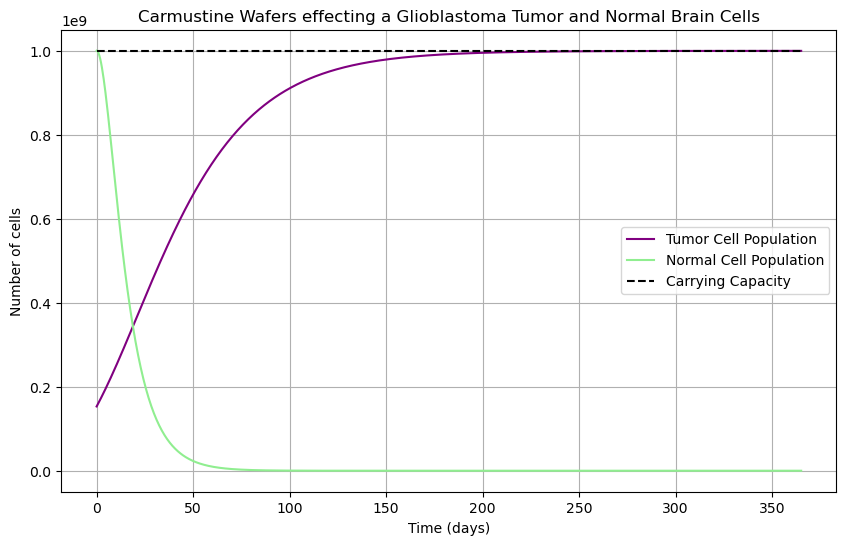

In [12]:
from scipy.integrate import solve_ivp
import numpy as np
import matplotlib.pyplot as plt

F = 12.3 #mg/day
km = 0.14
k = 0 #growth 
Pmax = 1e9
kg = 0.03
kill1 = 1e-7
ktox1 = 0.001 #more localized toxicity

#inital conidtions
m0 = 0
W0 = 1.53e8 #inital number of tumor cells in the patient
N0 = 1e9 #normal tissue
b0 = [m0, W0, N0]

def body_system_C(r, b):
    m, W, N = b
   
    #Slow release
    dmdt = F - km*m
    #Tumor growth
    dWdt = (-kg * W * np.log(W / Pmax)) - kill1*m*W
    #normal brain
    dNodt = -k*W*N - ktox1*m*N
  
    return [dmdt, dWdt, dNodt]

#Solve 
t = np.linspace(0,365, 800)
sol = solve_ivp(body_system_C, (t[0], t[-1]), b0, t_eval =t)

W = sol.y[1]
No = sol.y[2]
Carry = np.ones_like(t) * Pmax

plt.figure(figsize=(10,6))
plt.plot(t, W, 'purple', label='Tumor Cell Population')
plt.plot(t, No, 'lightgreen', label='Normal Cell Population')
plt.plot(t, Carry, 'k--', label='Carrying Capacity') 
plt.title('Carmustine Wafers effecting a Glioblastoma Tumor and Normal Brain Cells')
plt.xlabel('Time (days)')
plt.ylabel('Number of cells')
plt.legend()
plt.grid(True)
plt.show()

### Both Graphs Together

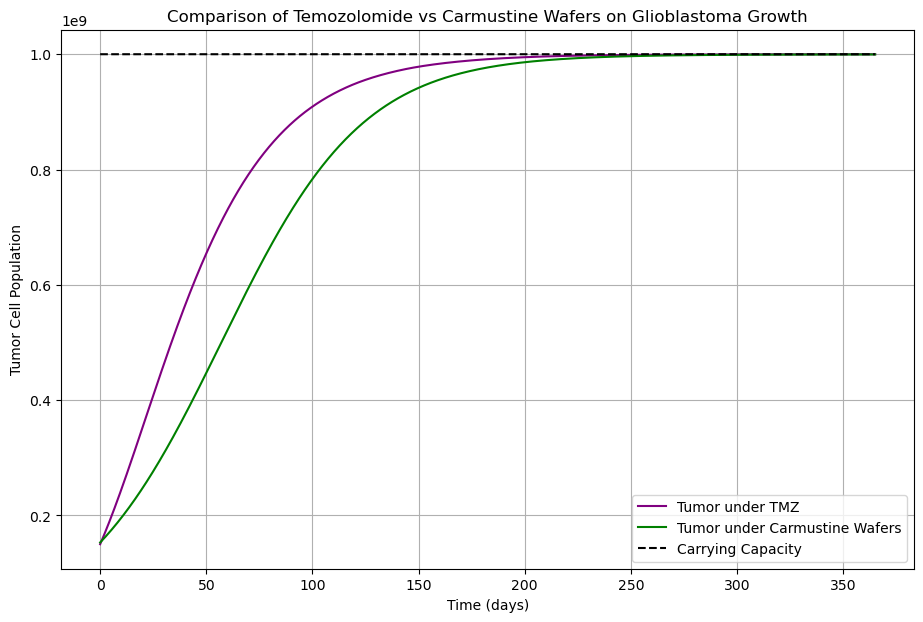

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def body_system_a(t, a):  
    y, Cp, Cb, Ct, P, N = a 
    
    # PK compartments
    dydt = -ka*y
    dCpdt = (ka*gamma*y) - (kpb*Cp) - (ke*Cp)
    dCbdt = (kpb*Cp) - (kbt*Cb)
    dCtdt = (kbt*Cb) - (kel*Ct)

    # PD compartments
    dPdt = (-kg * P * np.log(P / Pmax)) - kill * Ct * P
    dNdt = -ktox * Ct * N - beta * P * N
    
    return [dydt, dCpdt, dCbdt, dCtdt, dPdt, dNdt]


t_end = 365
t_points = [0]
a_points = [a0]
t_current = 0
a_current = np.array(a0)

for tdose in dose_times:
    sol = solve_ivp(body_system_a, (t_current, tdose), a_current,
                    t_eval=np.linspace(t_current, tdose, 200))
    
    # avoid duplicate times
    t_points.extend(sol.t[1:])
    a_points.extend(sol.y.T[1:])
    
    a_current = sol.y[:, -1]
    a_current[0] += dose  # bolus to gut
    
    t_current = tdose

sol = solve_ivp(body_system_a, (t_current, t_end), a_current,
                t_eval=np.linspace(t_current, t_end, 400))

t_points.extend(sol.t[1:])
a_points.extend(sol.y.T[1:])

t_points = np.array(t_points)
a_points = np.array(a_points)

P_tmz = a_points[:, 4]   # TMZ tumor population

def bcnu_system(t, y):
    m, W, N = y
    dmdt = F - km*m
    dWdt = kg*W*(1 - W/Pmax) - kill1*m*W
    dNdt = -ktox1*m*N - beta*W*N
    return [dmdt, dWdt, dNdt]

t2 = np.linspace(0, 365, 800)
sol2 = solve_ivp(bcnu_system, (0, 365), b0, t_eval=t2)

W_bcnu = sol2.y[1]

plt.figure(figsize=(11,7))

# tumor curves
plt.plot(t_points, P_tmz, color="purple", label="Tumor under TMZ")
plt.plot(t2, W_bcnu, color="green", label="Tumor under Carmustine Wafers")

# carrying capacity
plt.plot(t_points, np.ones_like(t_points)*Pmax, 'k--', label="Carrying Capacity")

plt.title("Comparison of Temozolomide vs Carmustine Wafers on Glioblastoma Growth")
plt.xlabel("Time (days)")
plt.ylabel("Tumor Cell Population")
plt.legend()
plt.grid(True)
plt.show()
